In [1]:
import os
import time
import copy
import torch
import shutil
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn, optim
import torch.nn.functional as F
from model_utils import (
    combine_datasets,
    split_dataset,
    count_images_in_directory,
    copy_images
)


In [6]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

valid_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


original_dataset_dir = '/workspace/archive/Lumpy Skin Images Dataset'
combined_dataset_dir = '/workspace/archive/combined_dataset'


original_normal_skin_dir = os.path.join(original_dataset_dir, 'Normal Skin')
original_lumpy_skin_dir = os.path.join(original_dataset_dir, 'Lumpy Skin')

combined_normal_skin_dir = os.path.join(combined_dataset_dir, 'Normal Skin')
combined_lumpy_skin_dir = os.path.join(combined_dataset_dir, 'Lumpy Skin')

original_train_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=train_transforms)
original_valid_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=valid_transforms)
combined_train_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=train_transforms)
combined_valid_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=valid_transforms)

original_train_loader = DataLoader(original_train_dataset, batch_size=32, shuffle=True)
original_valid_loader = DataLoader(original_valid_dataset, batch_size=32, shuffle=False)
combined_train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=True)
combined_valid_loader = DataLoader(combined_valid_dataset, batch_size=32, shuffle=False)


original_test_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=valid_transforms)
combined_test_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=valid_transforms)


original_test_loader = DataLoader(original_test_dataset, batch_size=32, shuffle=False)
combined_test_loader = DataLoader(combined_test_dataset, batch_size=32, shuffle=False)


print("Original Dataset (Training):")
print(f"Number of batches: {len(original_train_loader)}")
for images, labels in original_train_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nCombined Dataset (Training):")
print(f"Number of batches: {len(combined_train_loader)}")
for images, labels in combined_train_loader:
    print(f"Image batch size: {images.size()}")
    break

print("\nOriginal Dataset (Validation):")
print(f"Number of batches: {len(original_valid_loader)}")
for images, labels in original_valid_loader:
    print(f"Image batch size: {images.size()}")
    break

print("\nCombined Dataset (Validation):")
print(f"Number of batches: {len(combined_valid_loader)}")
for images, labels in combined_valid_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nOriginal Dataset (Test):")
print(f"Number of batches: {len(original_test_loader)}")
for images, labels in original_test_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nCombined Dataset (Test):")
print(f"Number of batches: {len(combined_test_loader)}")
for images, labels in combined_test_loader:
    print(f"Image batch size: {images.size()}")
    break


Original Dataset (Training):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Training):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])

Original Dataset (Validation):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Validation):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])

Original Dataset (Test):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Test):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])


In [7]:
import torch
import torch.nn as nn
from torchvision.models import inception_v3


base_model = inception_v3(pretrained=True, aux_logits=False)


for param in base_model.parameters():
    param.requires_grad = False

class CustomInceptionV3(nn.Module):
    def __init__(self, base_model):
        super(CustomInceptionV3, self).__init__()
        self.base_model = nn.Sequential(
            *list(base_model.children())[:-1]  
        )
        self.dropout = nn.Dropout(0.15)
        self.fc1 = nn.Linear(2048, 1024)  
        self.fc2 = nn.Linear(1024, 2)    

    def forward(self, x):
        
        x = self.base_model(x)
        x = x.view(x.size(0), -1)  
        
        x = self.dropout(x)
        
        x = self.fc1(x)
        
        x = self.fc2(x)
       
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
custom_model = CustomInceptionV3(base_model)
custom_model = custom_model.to(device)

print(custom_model)




CustomInceptionV3(
  (base_model): Sequential(
    (0): BasicConv2d(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicConv2d(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): BasicConv2d(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): BasicConv2d(
      (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (5): BasicConv2d(
      (conv): Conv2d(80, 192, kernel_size=(3, 3)

In [8]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
custom_model = custom_model.to(device)


from torchsummary import summary
input_size = (3, 299, 299)  
summary(custom_model, input_size)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 149, 149]             864
       BatchNorm2d-2         [-1, 32, 149, 149]              64
       BasicConv2d-3         [-1, 32, 149, 149]               0
            Conv2d-4         [-1, 32, 147, 147]           9,216
       BatchNorm2d-5         [-1, 32, 147, 147]              64
       BasicConv2d-6         [-1, 32, 147, 147]               0
            Conv2d-7         [-1, 64, 147, 147]          18,432
       BatchNorm2d-8         [-1, 64, 147, 147]             128
       BasicConv2d-9         [-1, 64, 147, 147]               0
        MaxPool2d-10           [-1, 64, 73, 73]               0
           Conv2d-11           [-1, 80, 73, 73]           5,120
      BatchNorm2d-12           [-1, 80, 73, 73]             160
      BasicConv2d-13           [-1, 80, 73, 73]               0
           Conv2d-14          [-1, 192,

In [9]:
learning_rate = 1e-4  
batch_size = 32

optimizer = optim.Adam(custom_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

original_train_loss_history = []
original_train_accuracy_history = []
original_valid_loss_history = []
original_valid_accuracy_history = []

combined_train_loss_history = []
combined_train_accuracy_history = []
combined_valid_loss_history = []
combined_valid_accuracy_history = []

model_dir = "./models2"
os.makedirs(model_dir, exist_ok=True)

def train_phase(train_loader, model, optimizer, criterion, dataset_name="Train"):
    model.train()  
    running_train_loss = 0.0
    correct_train_predictions = 0
    total_train_predictions = 0

    for inputs, labels in train_loader:
        
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)  
        _, predicted = torch.max(outputs, 1)
        correct_train_predictions += (predicted == labels).sum().item()
        total_train_predictions += labels.size(0)

    train_acc = correct_train_predictions / total_train_predictions
    train_loss = running_train_loss / len(train_loader.dataset)
    
    if dataset_name == "Original":
        original_train_loss_history.append(train_loss)
        original_train_accuracy_history.append(train_acc)
    else:
        combined_train_loss_history.append(train_loss)
        combined_train_accuracy_history.append(train_acc)
    
    print(f"{dataset_name} Phase: Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    
    return train_loss, train_acc


def validation_phase(valid_loader, model, criterion, dataset_name="Validation"):
    model.eval()  
    running_valid_loss = 0.0
    correct_valid_predictions = 0
    total_valid_predictions = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
        
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            
            running_valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_valid_predictions += (predicted == labels).sum().item()
            total_valid_predictions += labels.size(0)

    
    valid_acc = correct_valid_predictions / total_valid_predictions
    valid_loss = running_valid_loss / len(valid_loader.dataset)
    
  
    if dataset_name == "Original":
        original_valid_loss_history.append(valid_loss)
        original_valid_accuracy_history.append(valid_acc)
    else:
        combined_valid_loss_history.append(valid_loss)
        combined_valid_accuracy_history.append(valid_acc)
    
    print(f"{dataset_name} Phase: Loss: {valid_loss:.4f}, Accuracy: {valid_acc:.4f}")
    
    return valid_loss, valid_acc


def train_model(train_loader, valid_loader, model, optimizer, criterion, epochs=30, patience=5, dataset_name="Original"):
    """
    Main training loop for training the model.
    """
    best_model_wts = copy.deepcopy(model.state_dict()) 
    best_val_acc = 0.0
    early_stop_counter = 0


    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs} - Dataset: {dataset_name}")

        start_time = time.time()

        train_loss, train_acc = train_phase(train_loader, model, optimizer, criterion, dataset_name)

        valid_loss, valid_acc = validation_phase(valid_loader, model, criterion, dataset_name)

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_acc:.4f}")

        if valid_acc > best_val_acc:
            print(f"Validation accuracy improved from {best_val_acc:.4f} to {valid_acc:.4f}. Saving model.")
            best_val_acc = valid_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            model_path = os.path.join(model_dir, f"{dataset_name}_model_{epoch + 1:02d}-{valid_acc:.4f}.pth")
            torch.save(model.state_dict(), model_path)
            early_stop_counter = 0  
        else:
            print(f"Validation accuracy did not improve from {best_val_acc:.4f}")
            early_stop_counter += 1

        # Early stopping
        if early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch + 1} completed in {epoch_time:.2f} seconds.")

    # Load best model weights
    model.load_state_dict(best_model_wts)

    return model, best_val_acc


In [10]:
custom_model, best_val_acc_original = train_model(
    original_train_loader, 
    original_valid_loader, 
    custom_model, 
    optimizer, 
    criterion, 
    dataset_name="Original"
)



Epoch 1/30 - Dataset: Original
Original Phase: Loss: 0.5671, Accuracy: 0.7040
Original Phase: Loss: 0.4687, Accuracy: 0.7785
Train Loss: 0.5671, Train Accuracy: 0.7040
Validation Loss: 0.4687, Validation Accuracy: 0.7785
Validation accuracy improved from 0.0000 to 0.7785. Saving model.
Epoch 1 completed in 7.68 seconds.

Epoch 2/30 - Dataset: Original
Original Phase: Loss: 0.4643, Accuracy: 0.7932
Original Phase: Loss: 0.6074, Accuracy: 0.6847
Train Loss: 0.4643, Train Accuracy: 0.7932
Validation Loss: 0.6074, Validation Accuracy: 0.6847
Validation accuracy did not improve from 0.7785
Epoch 2 completed in 6.09 seconds.

Epoch 3/30 - Dataset: Original
Original Phase: Loss: 0.4166, Accuracy: 0.8134
Original Phase: Loss: 0.4336, Accuracy: 0.7702
Train Loss: 0.4166, Train Accuracy: 0.8134
Validation Loss: 0.4336, Validation Accuracy: 0.7702
Validation accuracy did not improve from 0.7785
Epoch 3 completed in 6.05 seconds.

Epoch 4/30 - Dataset: Original
Original Phase: Loss: 0.3837, Accur

In [11]:
custom_model_combined, best_val_acc_combined = train_model(
    combined_train_loader, 
    combined_valid_loader, 
    custom_model, 
    optimizer, 
    criterion, 
    dataset_name="Combined"
)



Epoch 1/30 - Dataset: Combined
Combined Phase: Loss: 0.4782, Accuracy: 0.7815
Combined Phase: Loss: 0.4714, Accuracy: 0.7595
Train Loss: 0.4782, Train Accuracy: 0.7815
Validation Loss: 0.4714, Validation Accuracy: 0.7595
Validation accuracy improved from 0.0000 to 0.7595. Saving model.
Epoch 1 completed in 16.59 seconds.

Epoch 2/30 - Dataset: Combined
Combined Phase: Loss: 0.4453, Accuracy: 0.7978
Combined Phase: Loss: 0.5301, Accuracy: 0.7241
Train Loss: 0.4453, Train Accuracy: 0.7978
Validation Loss: 0.5301, Validation Accuracy: 0.7241
Validation accuracy did not improve from 0.7595
Epoch 2 completed in 15.75 seconds.

Epoch 3/30 - Dataset: Combined
Combined Phase: Loss: 0.4453, Accuracy: 0.7973
Combined Phase: Loss: 0.3365, Accuracy: 0.8743
Train Loss: 0.4453, Train Accuracy: 0.7973
Validation Loss: 0.3365, Validation Accuracy: 0.8743
Validation accuracy improved from 0.7595 to 0.8743. Saving model.
Epoch 3 completed in 16.10 seconds.

Epoch 4/30 - Dataset: Combined
Combined Phase

In [12]:
# Training phase on Original Dataset
train_loss_original, train_accuracy_original = train_phase(
    train_loader=original_train_loader, 
    model=custom_model, 
    optimizer=optimizer, 
    criterion=criterion, 
    dataset_name="Original"
)

# Validation phase on Original Dataset
valid_loss_original, valid_accuracy_original = validation_phase(
    valid_loader=original_valid_loader, 
    model=custom_model, 
    criterion=criterion, 
    dataset_name="Original"
)

# Training phase on Combined Dataset
train_loss_combined, train_accuracy_combined = train_phase(
    train_loader=combined_train_loader, 
    model=custom_model, 
    optimizer=optimizer, 
    criterion=criterion, 
    dataset_name="Combined"
)

# Validation phase on Combined Dataset
valid_loss_combined, valid_accuracy_combined = validation_phase(
    valid_loader=combined_valid_loader, 
    model=custom_model, 
    criterion=criterion, 
    dataset_name="Combined"
)

# Test phase for Original Dataset
test_loss_original, test_acc_original = validation_phase(
    valid_loader=original_test_loader,
    model=custom_model,
    criterion=criterion,
    dataset_name="Original Test"
)

# Test phase for Combined Dataset
test_loss_combined, test_acc_combined = validation_phase(
    valid_loader=combined_test_loader,
    model=custom_model,
    criterion=criterion,
    dataset_name="Combined Test"
)

# Print the results
print(f"--- Original Dataset ---")
print(f"Training Loss: {train_loss_original:.4f}, Training Accuracy: {train_accuracy_original:.4f}")
print(f"Validation Loss: {valid_loss_original:.4f}, Validation Accuracy: {valid_accuracy_original:.4f}")
print(f"Test Loss: {test_loss_original:.4f}, Test Accuracy: {test_acc_original:.4f}")

print(f"\n--- Combined Dataset ---")
print(f"Training Loss: {train_loss_combined:.4f}, Training Accuracy: {train_accuracy_combined:.4f}")
print(f"Validation Loss: {valid_loss_combined:.4f}, Validation Accuracy: {valid_accuracy_combined:.4f}")
print(f"Test Loss: {test_loss_combined:.4f}, Test Accuracy: {test_acc_combined:.4f}")


Original Phase: Loss: 0.4172, Accuracy: 0.8088
Original Phase: Loss: 0.4270, Accuracy: 0.7877
Combined Phase: Loss: 0.4212, Accuracy: 0.8173
Combined Phase: Loss: 0.3533, Accuracy: 0.8552
Original Test Phase: Loss: 0.3570, Accuracy: 0.8392
Combined Test Phase: Loss: 0.3533, Accuracy: 0.8552
--- Original Dataset ---
Training Loss: 0.4172, Training Accuracy: 0.8088
Validation Loss: 0.4270, Validation Accuracy: 0.7877
Test Loss: 0.3570, Test Accuracy: 0.8392

--- Combined Dataset ---
Training Loss: 0.4212, Training Accuracy: 0.8173
Validation Loss: 0.3533, Validation Accuracy: 0.8552
Test Loss: 0.3533, Test Accuracy: 0.8552


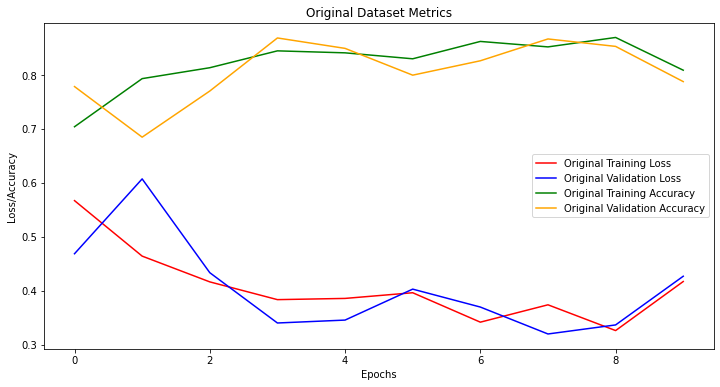

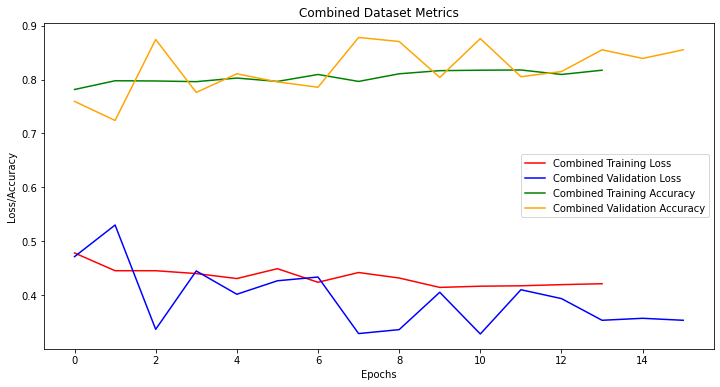

In [13]:
# Plot for original dataset
plt.figure(figsize=(12, 6))
plt.plot(original_train_loss_history, label="Original Training Loss", color='red')
plt.plot(original_valid_loss_history, label="Original Validation Loss", color='blue')
plt.plot(original_train_accuracy_history, label="Original Training Accuracy", color='green')
plt.plot(original_valid_accuracy_history, label="Original Validation Accuracy", color='orange')
plt.title("Original Dataset Metrics")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

# Plot for combined dataset
plt.figure(figsize=(12, 6))
plt.plot(combined_train_loss_history, label="Combined Training Loss", color='red')
plt.plot(combined_valid_loss_history, label="Combined Validation Loss", color='blue')
plt.plot(combined_train_accuracy_history, label="Combined Training Accuracy", color='green')
plt.plot(combined_valid_accuracy_history, label="Combined Validation Accuracy", color='orange')
plt.title("Combined Dataset Metrics")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()


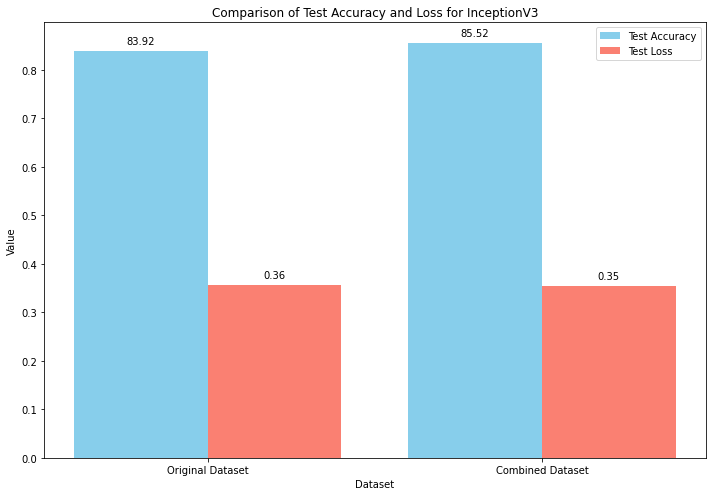

In [14]:
test_acc_values = [test_acc_original, test_acc_combined]
test_loss_values = [test_loss_original, test_loss_combined]

datasets = ['Original Dataset', 'Combined Dataset']

x = np.arange(len(datasets)) 
bar_width = 0.4  


fig, ax = plt.subplots(figsize=(10, 7))

bars1 = ax.bar(x - bar_width/2, test_acc_values, bar_width, label='Test Accuracy', color='skyblue')

bars2 = ax.bar(x + bar_width/2, test_loss_values, bar_width, label='Test Loss', color='salmon')

for bar, value in zip(bars1, test_acc_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.01,  
        f'{value * 100:.2f}',  
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

for bar, value in zip(bars2, test_loss_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.01,  
        f'{value:.2f}',  
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )


ax.set_xlabel('Dataset')
ax.set_ylabel('Value')
ax.set_title('Comparison of Test Accuracy and Loss for InceptionV3')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()


plt.tight_layout()
plt.show()


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

true_1, preds_1, probs_1 = evaluate_model(custom_model, original_test_loader, "Original", device)
true_2, preds_2, probs_2 = evaluate_model(custom_model, combined_test_loader, "Combined", device)



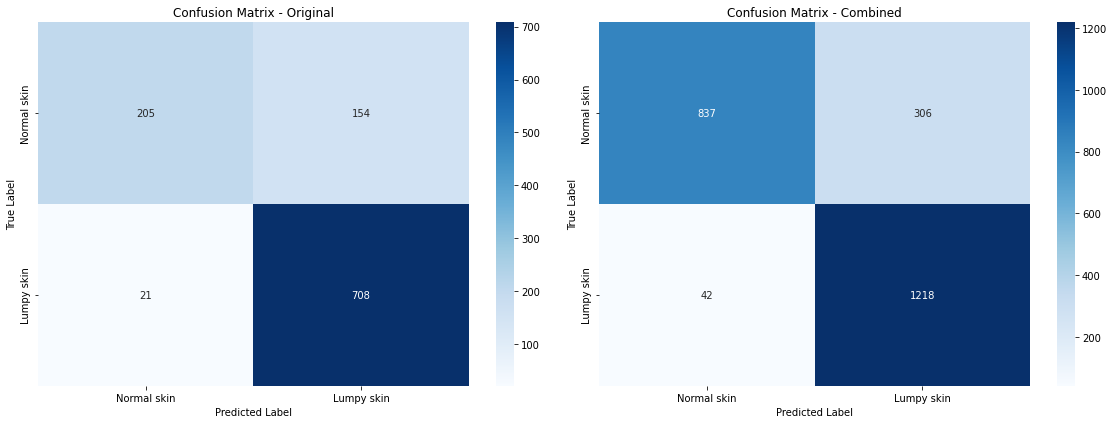

In [16]:

plot_confusion_matrices(true_1, preds_1, "Original", true_2, preds_2, "Combined")


In [17]:
# Print Metrics
print_metrics(true_1, preds_1, "Original", true_2, preds_2, "Combined")

Metrics for Original Dataset:
              precision    recall  f1-score   support

 Normal skin       0.91      0.57      0.70       359
  Lumpy skin       0.82      0.97      0.89       729

    accuracy                           0.84      1088
   macro avg       0.86      0.77      0.80      1088
weighted avg       0.85      0.84      0.83      1088

Mean Squared Error (MSE): 0.1608
Error Rate: 16.0846%

Metrics for Combined Dataset:
              precision    recall  f1-score   support

 Normal skin       0.95      0.73      0.83      1143
  Lumpy skin       0.80      0.97      0.88      1260

    accuracy                           0.86      2403
   macro avg       0.88      0.85      0.85      2403
weighted avg       0.87      0.86      0.85      2403

Mean Squared Error (MSE): 0.1448
Error Rate: 14.4819%



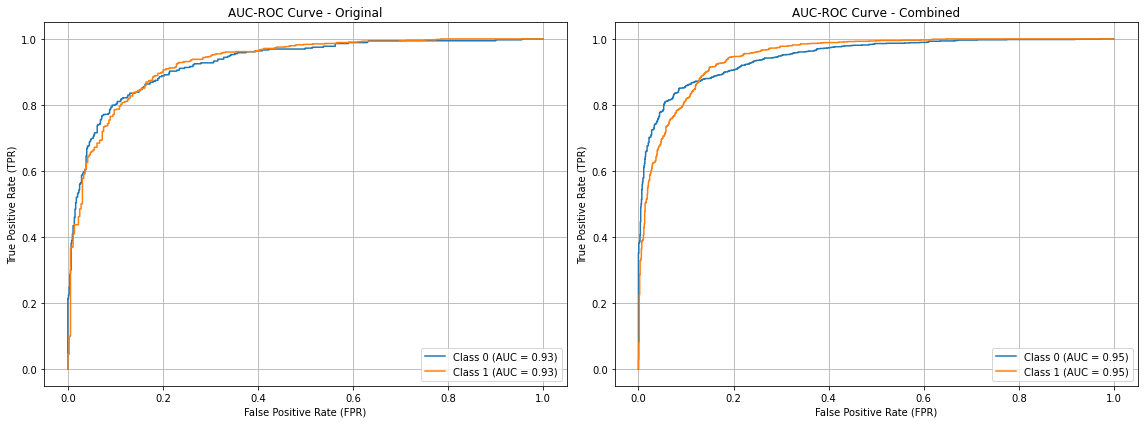

In [18]:
#plot AUC-ROC Curves
plot_auc_roc(true_1, probs_1, "Original", true_2, probs_2, "Combined")
